# TLS Traffic Anomaly Detection System Using Autoencoders
---

This notebook implements a system for analyzing TLS (Transport Layer Security) traffic patterns and detecting anomalies through autoencoder neural networks. 

The system processes TLS records from JSON files, extracts relevant features including cipher suites (tls.ccs), and learns normal traffic patterns.


After training on normal traffic, the system can evaluate new datasets by measuring reconstruction error to identify potential anomalies. 

The approach emphasizes processing cipher suite information by extracting the most frequent values and creating binary features to indicate their presence in each record.

## Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [2]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

## Setup and Imports

In [53]:
# Basic libraries
import math
import json
import glob
import os
import time
from datetime import datetime
from collections import Counter

# Data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and deep learning
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Keras components for deep learning
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

## Utility Functions
### Composite Number and Dimension Utilities
These functions help with determining optimal dimensions for visualization.

In [54]:
def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False

def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates

def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)

def get_padding_and_dim(x):
    """
    Find optimal dimensions for visualization by finding the nearest composite number
    that can be factored into dimensions with minimal difference.
    """
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1 - d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1 - d2) 
    return (val_x, val_d1, val_d2)

### Sequence Processing Utilities
These functions handle sequence padding and image creation for visualization.

In [55]:
def resize_row(row, maxlen, pad_value=0):
    """Resize a row in the array to the specified length."""
    current_length = len(row)
    if current_length < maxlen:
        pad_width = maxlen - current_length
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        row = row[:maxlen]
    return row

def make_image_from_sample(sample, image_pad, image_dim_x, image_dim_y):
    """Create a 2D image from a 1D sample with padding."""
    return np.pad(sample, pad_width=(0, image_pad), mode='constant', constant_values=0).reshape(image_dim_x, image_dim_y)

def pad_sequences(sequences, maxlen, padding='post', truncating='post', pad_value=0):
    """Pad sequences to a uniform length."""
    num_samples = len(sequences)
    padded_sequences = np.full((num_samples, maxlen), pad_value, dtype=float)
    
    for i, seq in enumerate(sequences):
        if not isinstance(seq, (list, np.ndarray)):
            continue
            
        seq = np.asarray(seq)
        if len(seq) == 0:
            continue
            
        if len(seq) >= maxlen:
            if truncating == 'pre':
                padded_sequences[i] = seq[-maxlen:]
            else:
                padded_sequences[i] = seq[:maxlen]
        else:
            if padding == 'pre':
                padded_sequences[i, -len(seq):] = seq
            else:
                padded_sequences[i, :len(seq)] = seq
                
    return padded_sequences

## Data Loading and Feature Extraction
### Cipher Suite (CCS) Processing Functions

In [58]:
def find_top_ccs_values(df, top_n):
    """
    Find the most common cipher suite values in the dataset.
    Returns a list of the top N most common values.
    """
    all_ccs = []
    for ccs_list in df['tls.ccs'].dropna():
        if isinstance(ccs_list, list):
            all_ccs.extend(ccs_list)
    
    # Calculate the frequency of each CCS value
    ccs_counter = Counter(all_ccs)
    
    # Get the most common CCS values
    top_ccs = [ccs for ccs, _ in ccs_counter.most_common(top_n)]
    
    print(f"Top {top_n} cipher suites: {top_ccs}")
    return top_ccs

def create_ccs_features(row, top_ccs):
    """
    Create binary features for each cipher suite in the top_ccs list.
    Returns a list of 0s and 1s indicating presence/absence of each cipher suite.
    """
    if not isinstance(row, list):
        return [0] * len(top_ccs)
    
    # Create a binary feature for each cipher suite
    return [1 if ccs in row else 0 for ccs in top_ccs]

def initialize_global_top_ccs(top_ccs):
    """Initialize the global top CCS list for consistent feature extraction."""
    global global_top_ccs
    global_top_ccs = top_ccs
    print(f"Initialized global top CCS list with {len(global_top_ccs)} values")

### JSON File Loading and Data Processing

In [ ]:
# Constants
RECORD_SEQUENCE_SIZE = 20
TOP_N_CCS = 30
TLS_COLUMNS_NAMES = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Global variable to store top CCS values
global_top_ccs = None

def load_json_files(json_files):
    """
    Load data from the specified collection of JSON files.
    Returns raw data as a DataFrame.
    """
    all_data = []
    # Open each file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            all_data.extend(data)
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

def extract_features(df, use_global_ccs=False):
    """
    Extract features from the raw dataset.
    
    This function processes:
    - Flow related columns: 'bs', 'ps', 'br', 'pr', 'td'
    - TLS handshake columns: 'tls.cver', 'tls.sver', 'tls.scs'
    - TLS record sizes: 'tls.rec'
    - CCS features: Binary indicators for the most common cipher suites
    
    Returns a DataFrame with the extracted features and the list of top CCS values used.
    """
    global global_top_ccs
    
    # Determine which top CCS values to use
    if use_global_ccs and global_top_ccs is not None:
        top_ccs = global_top_ccs
        print(f"Using global top CCS list with {len(top_ccs)} values")
    else:
        top_ccs = find_top_ccs_values(df, top_n=TOP_N_CCS)
        # If this is the first time extracting features, store the values globally
        if global_top_ccs is None:
            initialize_global_top_ccs(top_ccs)
    
    # Create binary features for cipher suites
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    ccs_features = df['tls.ccs'].apply(lambda x: create_ccs_features(x, top_ccs))
    ccs_df = pd.DataFrame(ccs_features.tolist(), columns=ccs_column_names)
    
    # Process flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    
    # Process TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    
    # Process TLS records 
    records_data = pd.DataFrame(
        pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), 
        columns=TLS_COLUMNS_NAMES
    )
    
    # Combine all features into a single dataset
    dataset = pd.concat([flow_data, tls_data, records_data, ccs_df], axis=1).fillna(0)
    return dataset, top_ccs

def fit_preprocessor(df, top_ccs):
    """
    Create and fit a preprocessing pipeline for the extracted features.
    
    This pipeline includes:
    - MinMaxScaler for numerical features
    - OneHotEncoder for categorical features
    
    Returns the fitted pipeline that can be used for transforming data.
    """
    # Define cipher suite columns
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    
    # Create the column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
            ('num_tls', MinMaxScaler(), TLS_COLUMNS_NAMES),
            ('num_ccs', MinMaxScaler(), ccs_column_names), 
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
        ])
    
    # Create the pipeline with the preprocessor
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    
    # Fit the pipeline on the data
    pipeline.fit(df)
    return pipeline

## Main Processing Pipeline
Put everything together and process our TLS traffic data.

In [71]:
# Load normal data (desktop application TLS traffic)
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'Dataset shape={raw_df.shape}')

# Extract features from the raw data
input_df, top_ccs = extract_features(raw_df)

# Store top CCS values globally for consistent feature extraction
global_top_ccs = top_ccs

# Create and fit the preprocessing pipeline
pipeline = fit_preprocessor(input_df, top_ccs)

# Transform the data using the pipeline
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])
print(f'Dataset shape={normal_df.shape}')

# Prepare for visualization
row_len = normal_df.shape[1]
(new_row_len, IMAGE_DIM_X, IMAGE_DIM_Y) = get_padding_and_dim(row_len)
IMAGE_PAD = new_row_len - row_len
print(f"Visualization adjustment: {row_len} -> {new_row_len} (+ {IMAGE_PAD}) [{IMAGE_DIM_X} x {IMAGE_DIM_Y}]")

# Split data into training and testing sets
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'Train dataset={x_train.shape}')
print(f'Test dataset(normal)={x_test.shape}')

def make_image_from_sample(sample):
    """Create a 2D image from a sample for visualization"""
    return np.pad(sample, pad_width=(0,IMAGE_PAD), mode='constant', constant_values=0).reshape(IMAGE_DIM_X, IMAGE_DIM_Y)


Dataset shape=(14962, 28)
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0039', '0067']
Initialized global top CCS list with 30 values
Normalized row of data:
[2.17753132e-03 2.21631206e-03 9.79934060e-05 8.92359175e-04
 6.24198375e-03 8.35066163e-01 9.25056978e-03 1.61063331e-02
 4.89771620e-01 9.18864858e-02 4.91283677e-02 1.96893508e-01
 5.67007398e-02 3.53978244e-01 2.29417032e-01 3.23067383e-01
 3.14913671e-01 2.98925203e-01 2.89292228e-01 5.08128222e-01
 5.07518224e-01 5.00594748e-01 4.98520755e-01 4.99557752e-01
 4.99557752e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00

## Autoencoder for Anomaly Detection

In this section, we implement an autoencoder neural network to learn normal TLS traffic patterns.
The autoencoder will compress the data into a lower-dimensional latent space and then attempt to reconstruct it. 
By measuring reconstruction error, we can identify abnormal traffic patterns.

### Autoencoder Architecture

In [83]:
# Define latent space size
LATENT_SPACE_SIZE = 6

# Split data into training and testing sets
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'Train dataset={x_train.shape}')
print(f'Test dataset(normal)={x_test.shape}')

# Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Input placeholder
input_img = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model for later use
encoder = Model(input_img, encoded)

# Decoder model setup
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# Compile and train the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=100,                      # use some more reasonable number here (>50)
                batch_size=16,
                shuffle=True,
                validation_data=(x_test, x_test))

Train dataset=(11969, 65)
Test dataset(normal)=(2993, 65)
Epoch 1/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - loss: 0.4299 - val_loss: 0.2302
Epoch 2/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step - loss: 0.2247 - val_loss: 0.2146
Epoch 3/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step - loss: 0.2127 - val_loss: 0.2048
Epoch 4/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - loss: 0.2020 - val_loss: 0.1971
Epoch 5/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step - loss: 0.1951 - val_loss: 0.1901
Epoch 6/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - loss: 0.1895 - val_loss: 0.1860
Epoch 7/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - loss: 0.1861 - val_loss: 0.1839
Epoch 8/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - loss: 0.1831 - val_loss: 0.1825
Epoch 9/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - loss: 0.1824 - val_loss: 0.1813
Epoch 10/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - loss: 0.1814 - val_loss: 0.1803
Epoch 11/100
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/

### Evaluating Reconstruction Performance

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step
Reconstruction error for each sample [0.0009613  0.00722028 0.00028008 ... 0.00222778 0.00079949 0.00339308]
Average=0.005848996261101028, Max=0.07821788626106828, Min=0.00025354190708532664 reconstruction errors.
Worst reconstructed:


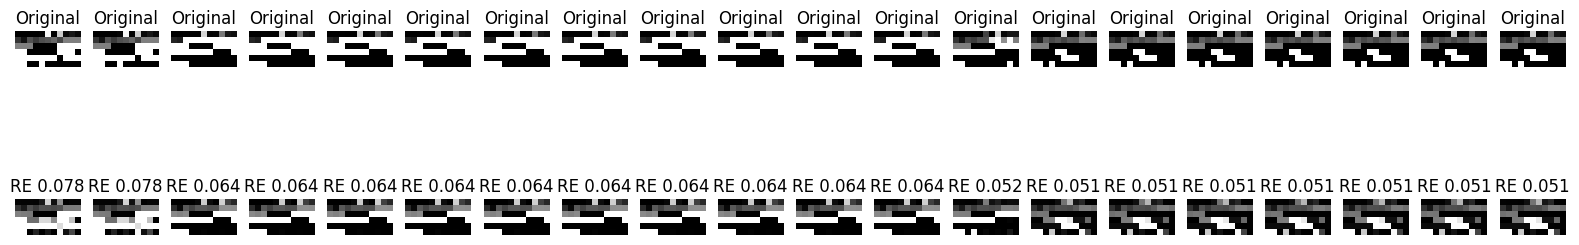

In [73]:
# Encode and decode test set
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Calculate reconstruction errors
reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

# Calculate statistics
avg_error = np.mean(reconstruction_errors)
max_error = np.max(reconstruction_errors)
min_error = np.min(reconstruction_errors)
print(f"Reconstruction error for each sample {reconstruction_errors}")
print(f"Average={avg_error}, Max={max_error}, Min={min_error} reconstruction errors.")

# Find worst reconstructed samples
worst20 = np.argsort(reconstruction_errors)[-20:][::-1]

# Visualize original vs reconstructed samples
n = 20  # Number of samples to display
i = 0

print("Worst reconstructed:")
plt.figure(figsize=(20, 4))
for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_from_sample(original) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_from_sample(reconstructed) 
    
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i+=1
plt.show()

## Testing Different TLS Datasets
Implement a function to test various TLS datasets using our trained autoencoder. This function will help us identify anomalous traffic patterns by measuring reconstruction errors.

### Dataset Testing Function

In [74]:
def test_dataset(json_files, top_ccs, dataset_name="Unnamed Dataset", export_results=False, results_file="tls_test_results.xlsx"):
    """
    Test a TLS dataset and print detailed results in English.
    
    Parameters:
    -----------
    json_files : list or glob pattern
        The JSON files containing TLS records to test
    top_ccs : list
        List of top CCS values used during training
    dataset_name : str
        Name of the dataset being tested (for reporting)
    export_results : bool
        Whether to export results to Excel file
    results_file : str
        Path to Excel file for exporting results
    """
    # Start timing
    start_time = time.time()
    
    # Load and process data
    raw_test_df = load_json_files(json_files)
    
    # Find this dataset's own top CCS values (for analysis purposes)
    dataset_top_ccs = find_top_ccs_values(raw_test_df, top_n=TOP_N_CCS)
    print(f"Top 30 cipher suites in {dataset_name}: {dataset_top_ccs}")
    
    # Compare with training dataset's CCS values
    common_ccs = set(dataset_top_ccs) & set(top_ccs)
    unique_ccs = set(dataset_top_ccs) - set(top_ccs)
    print(f"CCS values in common with training data: {len(common_ccs)}")
    print(f"CCS values unique to this dataset: {len(unique_ccs)}")
    if unique_ccs:
        print(f"Unique CCS values: {', '.join(list(unique_ccs)[:10])}")
    
    # Use training top CCS for feature extraction to ensure model compatibility
    input_test_df, _ = extract_features(raw_test_df, use_global_ccs=True)
    
    # Transform data using the pipeline
    test_df = pipeline.transform(input_test_df)
    print(f"Processed dataset shape: {test_df.shape} ({test_df.shape[0]} samples with {test_df.shape[1]} features)")
    
    # Encode and decode using the autoencoder
    encoded_test = encoder.predict(test_df)
    decoded_test = decoder.predict(encoded_test)
        
    # Calculate reconstruction errors
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    
    # Calculate statistics
    test_avg_error = np.mean(test_reconstruction_errors)
    test_median_error = np.median(test_reconstruction_errors)
    test_std_error = np.std(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    
    # Get percentiles for better distribution understanding
    percentiles = [25, 50, 75, 90, 95, 99]
    error_percentiles = np.percentile(test_reconstruction_errors, percentiles)
    
    # Get best and worst samples
    best10 = np.argsort(test_reconstruction_errors)[:10]
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    # Visualize results
    n = 10  # Number of samples to display
    plt.figure(figsize=(20, 4))
    for i, j in enumerate(worst10):
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed)
        
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
    
    plt.suptitle(f"Worst Reconstructed Samples - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    # Performance summary
    print("\nPERFORMANCE SUMMARY:")
    print(f"Dataset: {dataset_name}")
    print(f"Number of samples: {raw_test_df.shape[0]}")
    print(f"Number of features: {test_df.shape[1]}")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Processing time: {elapsed_time:.2f} seconds")
    
    # Export results if requested
    if export_results:
        # Prepare results dictionary
        results_dict = {
            'Dataset Name': dataset_name,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Number of Samples': raw_test_df.shape[0],
            'Number of Features': test_df.shape[1],
            'Average Error': test_avg_error,
            'Median Error': test_median_error,
            'Std Deviation': test_std_error,
            'Min Error': test_min_error,
            'Max Error': test_max_error,
            'Processing Time (s)': elapsed_time
        }
        
        # Add percentiles
        for p, val in zip(percentiles, error_percentiles):
            results_dict[f'Percentile {p}'] = val
        
        # Create DataFrame
        results_df = pd.DataFrame([results_dict])
        
        try:
            # Check if file exists
            if os.path.exists(results_file):
                existing_results = pd.read_excel(results_file)
                updated_results = pd.concat([existing_results, results_df], ignore_index=True)
            else:
                updated_results = results_df
                
            # Save to Excel
            updated_results.to_excel(results_file, index=False)
            print(f"\nResults successfully exported to {results_file}")
            
        except Exception as e:
            pass
    
    return {
        'dataset_name': dataset_name,
        'avg_error': test_avg_error,
        'median_error': test_median_error,
        'std_error': test_std_error,
        'min_error': test_min_error,
        'max_error': test_max_error,
        'raw_shape': raw_test_df.shape,
        'processed_shape': test_df.shape,
        'errors': test_reconstruction_errors,
        'top_ccs': dataset_top_ccs
    }

### Testing Multiple Datasets
Test autoencoder on various TLS traffic datasets to compare reconstruction errors.

Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0039', '0067']
Top 30 cipher suites: ['002F', '0035', '000A', 'C00A', 'C009', 'C013', 'C014', 'C02B', '0005', '0004', '0033', '0039', '0032', 'C02F', 'C007', 'C011', '0038', '0045', '0088', '0016', '0041', '0084', 'C012', '009E', '009C', '003D', '003C', 'C023', 'C027', '0013']
Top 30 cipher suites in ISCX TLS Dataset: ['002F', '0035', '000A', 'C00A', 'C009', 'C013', 'C014', 'C02B', '0005', '0004', '0033', '0039', '0032', 'C02F', 'C007', 'C011', '0038', '0045', '0088', '0016', '0041', '0084', 'C012', '009E', '009C', '003D', '003C', 'C023', 'C027', '0013']
CCS values in common with training data: 16
CCS values unique to this dataset: 14
Unique CCS values: 0005, 0088, 0032, 0038, 0084, 0013, 0016, 0004, C011, 0045
Using global top CCS list with 

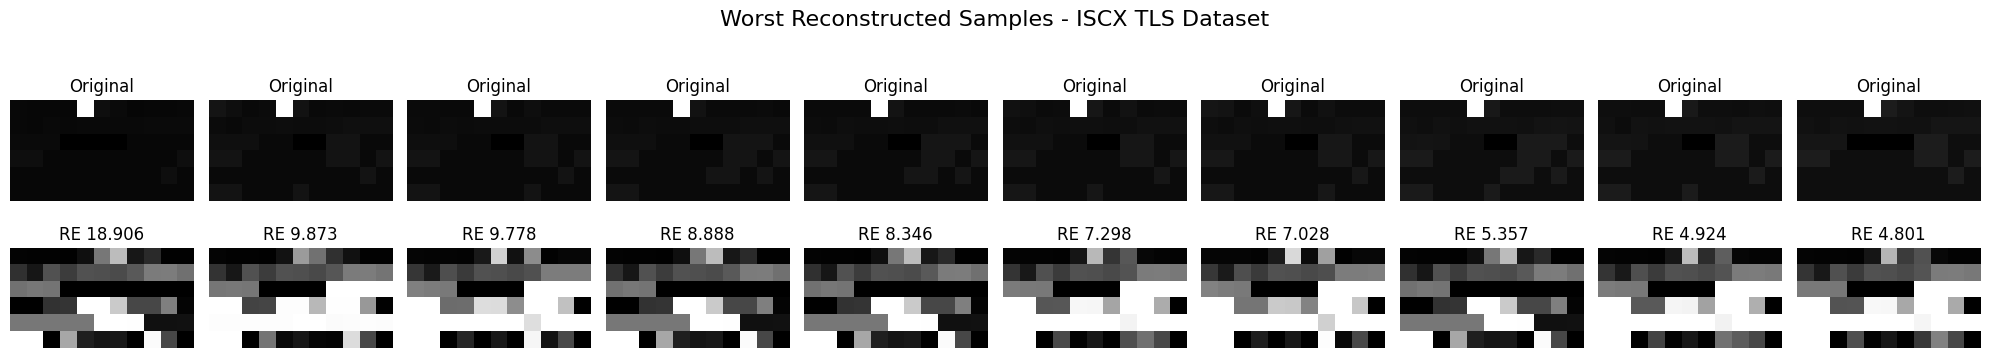


PERFORMANCE SUMMARY:
Dataset: ISCX TLS Dataset
Number of samples: 1112
Number of features: 65
Average reconstruction error: 0.335657
Processing time: 0.21 seconds
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
Top 30 cipher suites in Mobile TLS Dataset: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
CCS values in common with training data: 27
CCS values unique to this dataset: 3
Unique CCS values: C012, CCAA, C008
Using global top CCS list with 30 values
Processed dataset shape: (5616, 65) (5616 samples with 65 features)
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step
176/176 ━━━━━━━━━━━

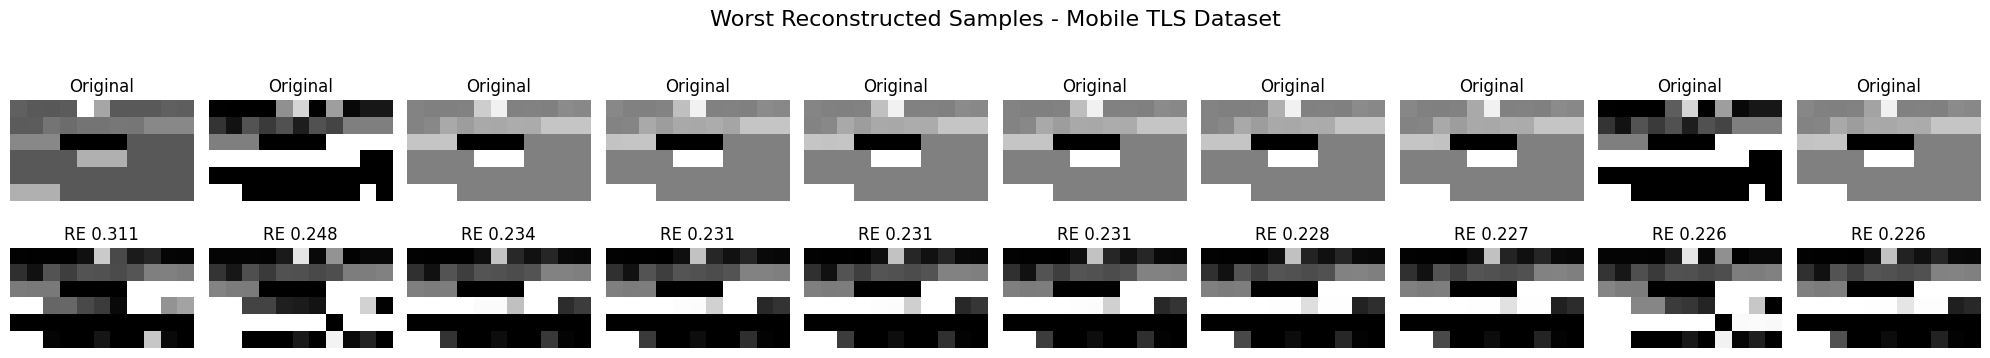


PERFORMANCE SUMMARY:
Dataset: Mobile TLS Dataset
Number of samples: 5616
Number of features: 65
Average reconstruction error: 0.026417
Processing time: 0.60 seconds
Top 30 cipher suites: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
Top 30 cipher suites in Windows TLS Dataset: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
CCS values in common with training data: 30
CCS values unique to this dataset: 0
Using global top CCS list with 30 values
Processed dataset shape: (15047, 65) (15047 samples with 65 features)
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step


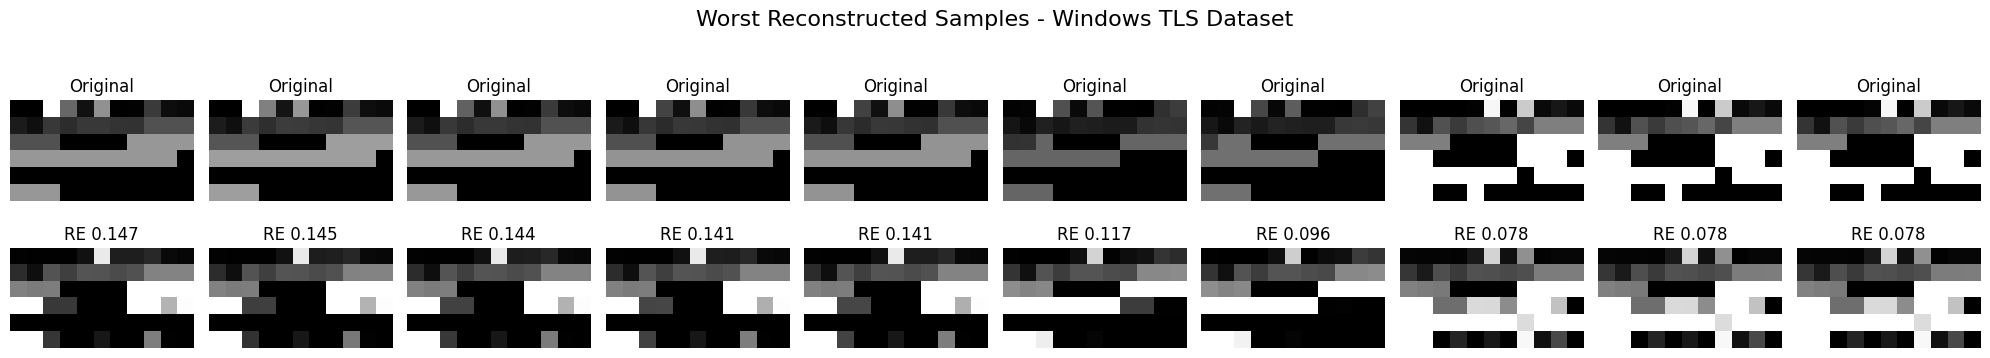


PERFORMANCE SUMMARY:
Dataset: Windows TLS Dataset
Number of samples: 15047
Number of features: 65
Average reconstruction error: 0.005899
Processing time: 2.04 seconds
Top 30 cipher suites: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
Top 30 cipher suites in CIC-AA Normal TLS Dataset: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0005, 0009, CC13, 0003, 0006, 0004, C011, CC14, C007, 0008
Using global top CCS list with 30 values
Processed dataset shape: (31179, 65) (31179 samples with 65 features)
975/97

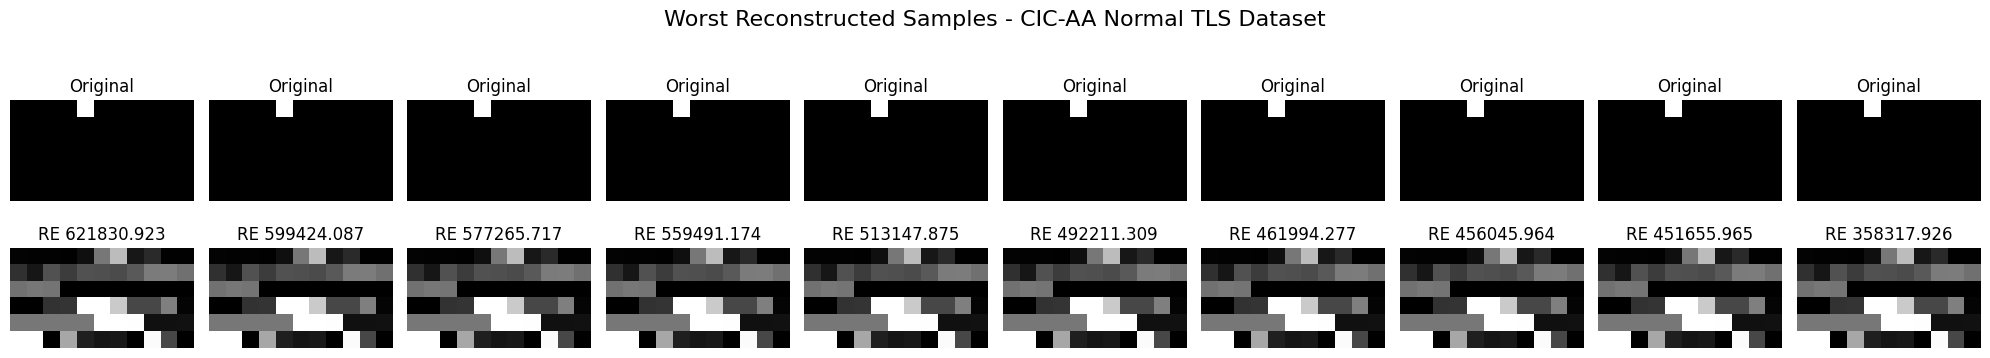


PERFORMANCE SUMMARY:
Dataset: CIC-AA Normal TLS Dataset
Number of samples: 31179
Number of features: 65
Average reconstruction error: 379.349310
Processing time: 3.26 seconds
Top 30 cipher suites: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
Top 30 cipher suites in CIC-AA Malware TLS Dataset: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0005, 0009, CC13, 0003, 0006, 0004, C011, CC14, C007, 0008
Using global top CCS list with 30 values
Processed dataset shape: (462, 65) (462 samples with 65 features)
1

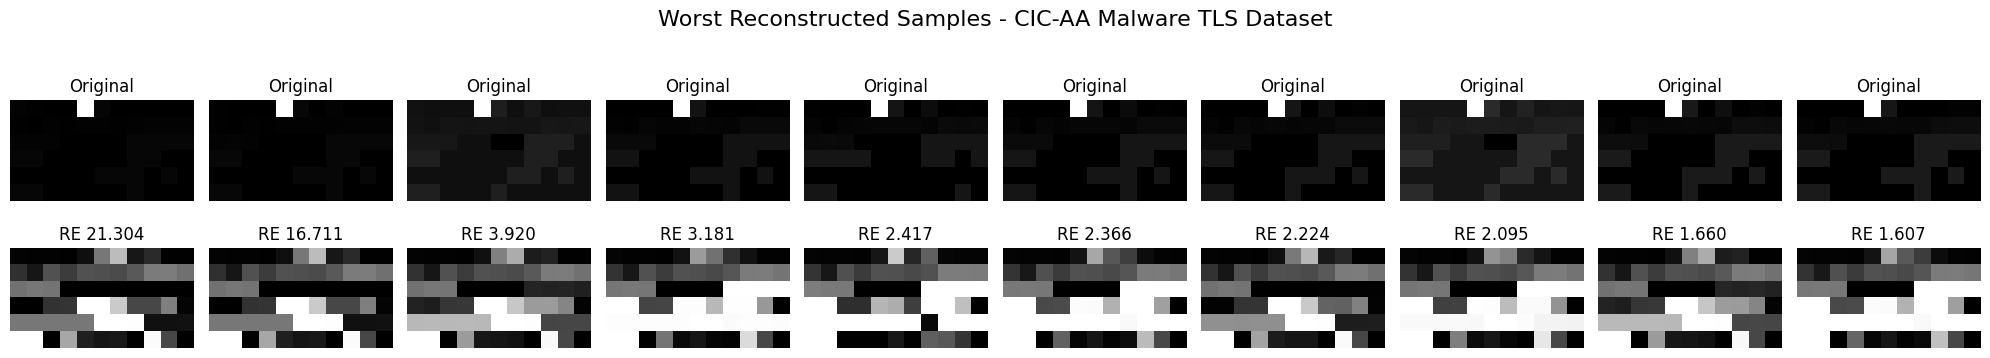


PERFORMANCE SUMMARY:
Dataset: CIC-AA Malware TLS Dataset
Number of samples: 462
Number of features: 65
Average reconstruction error: 0.436342
Processing time: 0.15 seconds
Top 30 cipher suites: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
Top 30 cipher suites in CIC-AA Adware TLS Dataset: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 00A3, 0005, CC13, C022, C021, 0004, C011, CC15, CC14, C007
Using global top CCS list with 30 values
Processed dataset shape: (7122, 65) (7122 samples with 65 features)
223

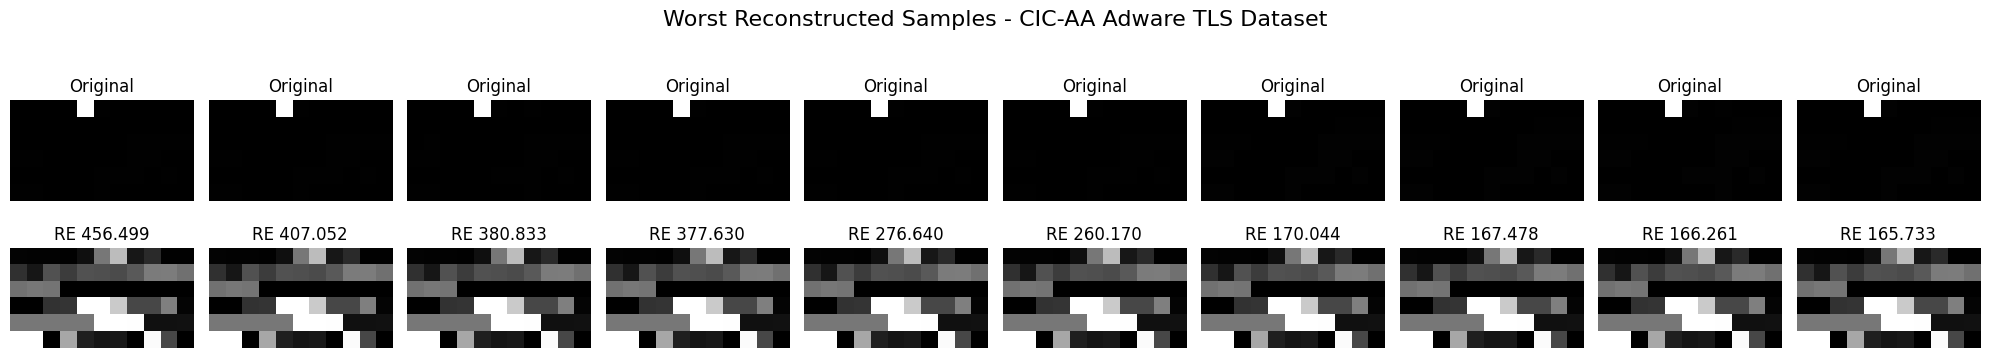


PERFORMANCE SUMMARY:
Dataset: CIC-AA Adware TLS Dataset
Number of samples: 7122
Number of features: 65
Average reconstruction error: 0.948788
Processing time: 0.76 seconds

COMPARISON OF DATASETS
                   Dataset  Samples  Features  Avg Error     Max Error  Min Error
          ISCX TLS Dataset     1112        65   0.335657     18.906013   0.046143
        Mobile TLS Dataset     5616        65   0.026417      0.310824   0.000560
       Windows TLS Dataset    15047        65   0.005899      0.146601   0.000251
 CIC-AA Normal TLS Dataset    31179        65 379.349310 621830.922666   0.019799
CIC-AA Malware TLS Dataset      462        65   0.436342     21.303705   0.025946
 CIC-AA Adware TLS Dataset     7122        65   0.948788    456.498674   0.035878


In [75]:
# Store results in a dictionary
results = {}

# Get the top CCS values from our training data
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
input_df, top_ccs = extract_features(raw_df)

# Test ISCX dataset
results['iscx'] = test_dataset(
    json_files=glob.glob("../datasets/iscx.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="ISCX TLS Dataset",
    export_results=True
)

# Test Mobile dataset
results['mobile'] = test_dataset(
    glob.glob("../datasets/mobile.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Mobile TLS Dataset",
    export_results=True
)

# Test Windows dataset
results['windows'] = test_dataset(
    glob.glob("../datasets/windows.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Windows TLS Dataset",
    export_results=True
)

# Test cic-aa.normal datasets
results['cic-aa.normal'] = test_dataset(
    glob.glob("../datasets/cic-aa.normal.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Normal TLS Dataset",
    export_results=True
)

# Test cic-aa.malware datasets
results['cic-aa.malware'] = test_dataset(
    glob.glob("../datasets/cic-aa.malware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Malware TLS Dataset",
    export_results=True
)

# Test cic-aa.adware datasets
results['cic-aa.adware'] = test_dataset(
    glob.glob("../datasets/cic-aa.adware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Adware TLS Dataset",
    export_results=True
)

# Compare datasets
print("\n" + "="*80)
print("COMPARISON OF DATASETS")
print("="*80)

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Dataset': result['dataset_name'],
        'Samples': result['raw_shape'][0],
        'Features': result['processed_shape'][1],
        'Avg Error': result['avg_error'],
        'Max Error': result['max_error'],
        'Min Error': result['min_error']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

## Reconstruction

In this section, threshold tuning was performed to optimize the anomaly detection process. Metrics such as recall, precision, and accuracy were observed across different threshold values to identify the optimal threshold for anomaly classification. The recall metric was particularly emphasized to ensure the detection of as many anomalies as possible.

For further details and reference, the implementation was inspired by the following repository:  
[Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/blob/main/anomaly-detection-with-autoencoders.ipynb)


In [77]:
# Define constants for dataset labels
NORMAL_LABEL = 'Normal dataset (Desktop.tls)'
MALICIOUS_LABEL = 'Malicious dataset (Adware.tls)'

# load the malicious dataset
abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.adware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.malware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/iscx.tls/*.json"))

input_abnormal_df, _ = extract_features(abnormal_raw_df, use_global_ccs=True)
    
abnormal_df = pipeline.transform(input_abnormal_df)

# calculate reconstruction errors for abnormal data
encoded_abnormal = encoder.predict(abnormal_df)
decoded_abnormal = decoder.predict(encoded_abnormal)
errors_abnormal = np.mean(np.square(abnormal_df - decoded_abnormal), axis=1)

# create a DataFrame for the reconstruction errors
recons_abnormal_df = pd.DataFrame({
    'error': errors_abnormal,
    'y_true': [MALICIOUS_LABEL] * len(errors_abnormal)
})

# let normal_df be the normal data
recons_normal_df = pd.DataFrame({
    'error': reconstruction_errors,
    'y_true': [NORMAL_LABEL] * len(reconstruction_errors)
})

recons_df = pd.concat([recons_normal_df, recons_abnormal_df], ignore_index=True)
recons_df.head()

Using global top CCS list with 30 values
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step


,error,y_true
0,0.000961,Normal dataset (Desktop.tls)
1,0.007220,Normal dataset (Desktop.tls)
2,0.000280,Normal dataset (Desktop.tls)
3,0.002845,Normal dataset (Desktop.tls)
4,0.011361,Normal dataset (Desktop.tls)


In [80]:
def thresholdTuning(df, iterations):
    # Create a mapping of string labels to numeric values for classification metrics
    label_mapping = {
        NORMAL_LABEL: 0,
        MALICIOUS_LABEL: 1
    }

    # Convert string labels to numeric for classification report
    y_true_numeric = df['y_true'].map(label_mapping)

    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }

    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = (df['error'] > thresh_value).astype(int)  # Convert boolean to int
        cr = classification_report(y_true_numeric, preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']

        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)

        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")

    return pd.DataFrame(thresh_df)

# Run threshold tuning with 100 iterations
thresh_df = thresholdTuning(recons_df, 100)

# Select the threshold with maximum recall
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold: 0.0003	Accuracy: 0.704		Precision: 0.852	Recall Score: 0.500
Threshold: 0.0004	Accuracy: 0.714		Precision: 0.856	Recall Score: 0.517
Threshold: 0.0004	Accuracy: 0.724		Precision: 0.859	Recall Score: 0.534
Threshold: 0.0006	Accuracy: 0.734		Precision: 0.863	Recall Score: 0.551
Threshold: 0.0007	Accuracy: 0.744		Precision: 0.867	Recall Score: 0.568
Threshold: 0.0008	Accuracy: 0.754		Precision: 0.871	Recall Score: 0.585
Threshold: 0.0009	Accuracy: 0.764		Precision: 0.875	Recall Score: 0.601
Threshold: 0.0010	Accuracy: 0.774		Precision: 0.879	Recall Score: 0.618
Threshold: 0.0011	Accuracy: 0.784		Precision: 0.883	Recall Score: 0.635
Threshold: 0.0013	Accuracy: 0.794		Precision: 0.887	Recall Score: 0.652
Threshold: 0.0015	Accuracy: 0.804		Precision: 0.891	Recall Score: 0.669
Threshold: 0.0016	Accuracy: 0.814		Precision: 0.896	Recall Score: 0.686
Threshold: 0.0019	Accuracy: 0.824		Precision: 0.900	Recall Score: 0.703
Threshold: 0.0021	Accuracy: 0.834		Precision: 0.905	Recall Score

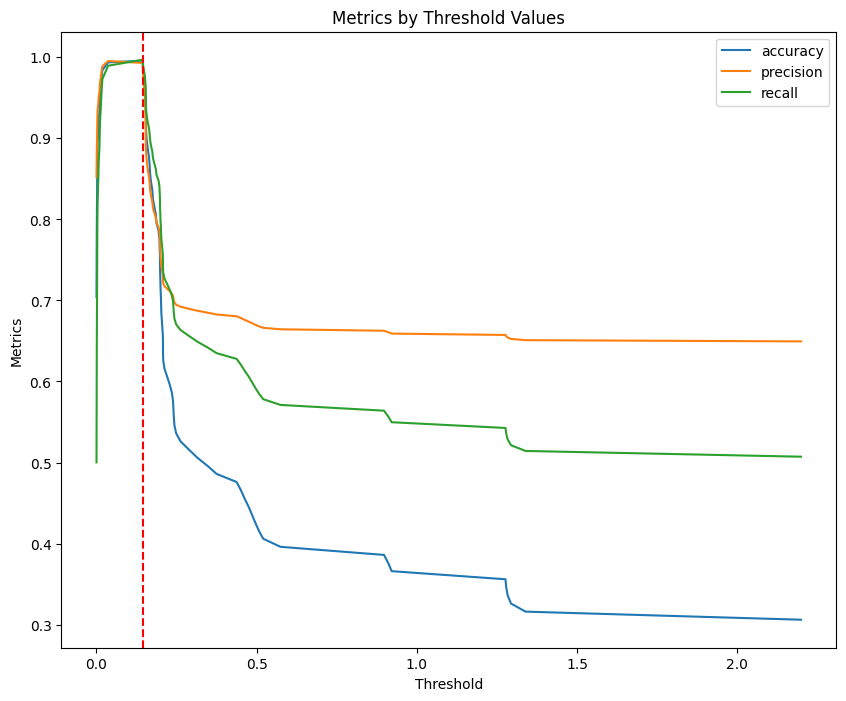

In [81]:
# Plot metrics by threshold values
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

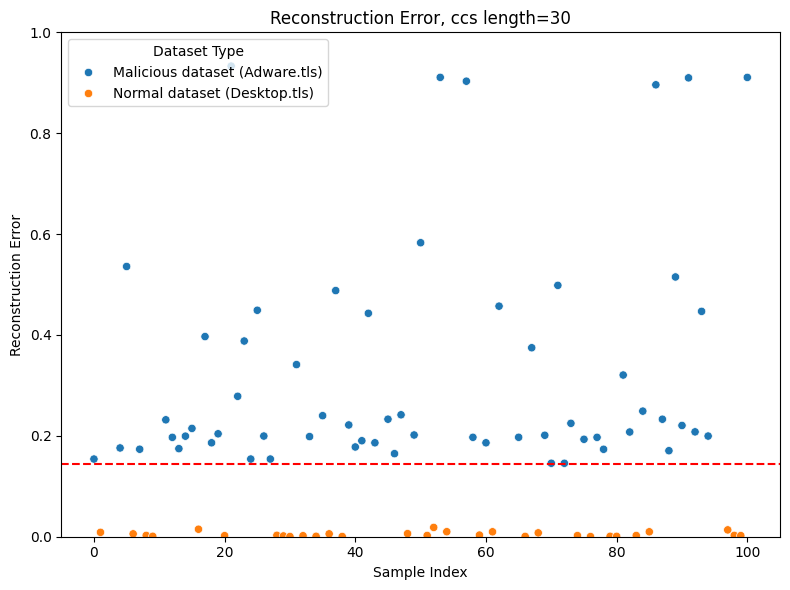

In [82]:
# Visualize reconstruction errors with the selected threshold
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.ylim(0, 1)  
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title(f'Reconstruction Error, ccs length={TOP_N_CCS}')
plt.legend(title='Dataset Type')
plt.tight_layout()
plt.show()